# Kaplan-Meier Survival Analysis in R

## Overview

Survival analysis models **time-to-event** data. The defining challenge is **censoring**: subjects that have not yet experienced the event by the end of observation. Censored observations are not missing data — they contribute real information and must be handled correctly.

| Censoring type | Meaning |
|---|---|
| **Right** (most common) | Event had not occurred by end of study or follow-up |
| **Left** | Event occurred before observation began |
| **Interval** | Event occurred in a known window but exact time is unknown |

The **Kaplan-Meier estimator** is a non-parametric estimate of the survival function S(t) = P(T > t). It steps down only at observed event times; censored observations drop from the risk set without reducing S(t).

The **log-rank test** tests H₀: survival functions are identical across groups. It is most powerful when hazards are proportional (curves do not cross).

## Applications by Sector

| Sector | Time | Event | Censoring example |
|---|---|---|---|
| **Ecology** | Days since patch creation | First colonisation | Study ended before colonisation |
| **Healthcare** | Months post-diagnosis | Death or recurrence | Lost to follow-up |
| **Engineering** | Hours of operation | Equipment failure | Still operating at inspection |
| **Insurance** | Months since policy | Claim filed | Policy cancelled |

---

## Setup

In [1]:
library(tidyverse)
library(survival)    # Surv(), survfit(), survdiff()
library(survminer)   # ggsurvplot()
library(broom)       # tidy() for survfit objects

set.seed(42)

# ── Simulate: days to invertebrate colonisation, three habitat types ───────────
n <- 150
habitat_data <- tibble(
  id      = 1:n,
  habitat = rep(c("reference", "restored", "degraded"), each = n / 3),
  true_t  = c(
    rexp(n/3, rate = 0.10),   # reference: fastest colonisation
    rexp(n/3, rate = 0.06),   # restored:  moderate
    rexp(n/3, rate = 0.03)    # degraded:  slowest
  )
) %>%
  mutate(
    habitat = factor(habitat, levels = c("reference", "restored", "degraded")),
    status  = as.integer(true_t <= 30),  # 1 = event observed, 0 = right-censored
    time    = pmin(true_t, 30)           # study ends at day 30
  )

cat(sprintf("%d / %d events observed (%.0f%% censored)\n",
            sum(habitat_data$status), n,
            (1 - mean(habitat_data$status)) * 100))
count(habitat_data, habitat, status)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'survival' was built under R version 4.4.3"
Warning message:
"package 'survminer' was built under R version

119 / 150 events observed (21% censored)


habitat,status,n
<fct>,<int>,<int>
reference,0,5
reference,1,45
restored,0,5
restored,1,45
degraded,0,21
degraded,1,29


---

## The `Surv` Object

In [2]:
# Surv() encodes time and event status together
# Censored observations displayed with '+'
surv_obj <- Surv(time = habitat_data$time, event = habitat_data$status)
head(surv_obj, 12)

 [1]  1.983368  6.608953  2.834910  0.381919  4.731766 14.636271  3.139846
 [8]  4.101296 11.915978  7.148625 13.447156 24.086844

---

## Kaplan-Meier Estimation

In [3]:
km_fit <- survfit(
  Surv(time, status) ~ habitat,
  data      = habitat_data,
  conf.type = "log-log"   # recommended for small samples; default is "plain"
)
print(km_fit)
# For each group: n, events, median survival time (95% CI)

# Tidy output — one row per event time per group
km_tidy <- broom::tidy(km_fit)
glimpse(km_tidy)

Call: survfit(formula = Surv(time, status) ~ habitat, data = habitat_data, 
    conf.type = "log-log")

                   n events median 0.95LCL 0.95UCL
habitat=reference 50     45   6.59    4.10    11.9
habitat=restored  50     45   9.24    7.32    16.5
habitat=degraded  50     29  25.06   16.21      NA
Rows: 122
Columns: 9
$ time      <dbl> 0.2881542, 0.2882587, 0.3819190, 0.5714136, 0.9614656, 1.983…
$ n.risk    <dbl> 50, 49, 48, 47, 46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, …
$ n.event   <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ n.censor  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ estimate  <dbl> 0.98, 0.96, 0.94, 0.92, 0.90, 0.88, 0.86, 0.84, 0.82, 0.80, …
$ std.error <dbl> 0.02020305, 0.02886751, 0.03572948, 0.04170288, 0.04714045, …
$ conf.high <dbl> 0.9971583, 0.9898434, 0.9802452, 0.9691986, 0.9571107, 0.944…
$ conf.low  <dbl> 0.8663856, 0.8493874, 0.8254029, 0.8007346, 0.7762858, 0.752…
$ strata    <chr> "habitat=refe

---

## Log-Rank Test

In [4]:
# Omnibus test: are all three curves equal?
lr <- survdiff(
  Surv(time, status) ~ habitat,
  data = habitat_data,
  rho  = 0    # rho=0: log-rank (equal weight); rho=1: Peto-Peto (early differences)
)
print(lr)
lr_p <- 1 - pchisq(lr$chisq, df = length(lr$n) - 1)
cat(sprintf("Log-rank: chi2=%.3f, df=%d, p=%.4f\n", lr$chisq, length(lr$n) - 1, lr_p))

# Pairwise tests with BH correction
pairs <- combn(levels(habitat_data$habitat), 2, simplify = FALSE)
pairwise_lr <- map_dfr(pairs, function(grps) {
  sub <- filter(habitat_data, habitat %in% grps) %>% mutate(habitat = droplevels(habitat))
  res <- survdiff(Surv(time, status) ~ habitat, data = sub)
  tibble(
    pair   = paste(grps, collapse = " vs. "),
    chi_sq = round(res$chisq, 3),
    p_raw  = round(1 - pchisq(res$chisq, df = 1), 4)
  )
}) %>% mutate(p_adj = round(p.adjust(p_raw, "BH"), 4))
print(pairwise_lr)

Call:
survdiff(formula = Surv(time, status) ~ habitat, data = habitat_data, 
    rho = 0)

                   N Observed Expected (O-E)^2/E (O-E)^2/V
habitat=reference 50       45     26.9     12.25     16.25
habitat=restored  50       45     36.6      1.91      2.78
habitat=degraded  50       29     55.5     12.65     24.66

 Chisq= 28  on 2 degrees of freedom, p= 8e-07 
Log-rank: chi2=28.007, df=2, p=0.0000
# A tibble: 3 × 4
  pair                   chi_sq  p_raw  p_adj
  <chr>                   <dbl>  <dbl>  <dbl>
1 reference vs. restored   2.32 0.128  0.128 
2 reference vs. degraded  25.6  0      0     
3 restored vs. degraded   15.8  0.0001 0.0002


---

## Kaplan-Meier Plot

Ignoring unknown labels:
• colour : "Strata"


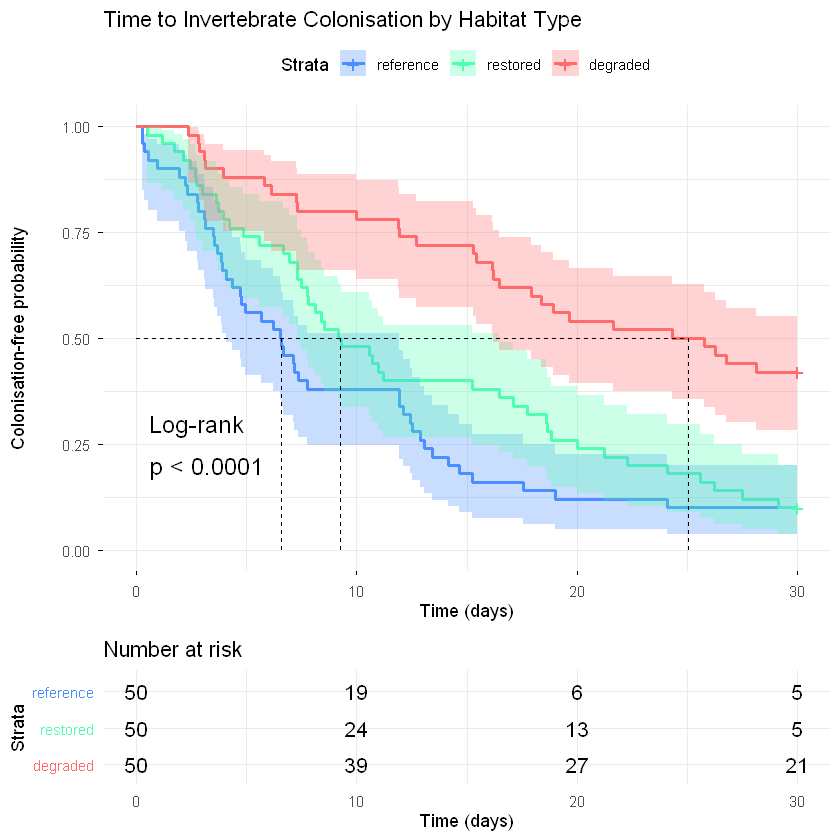

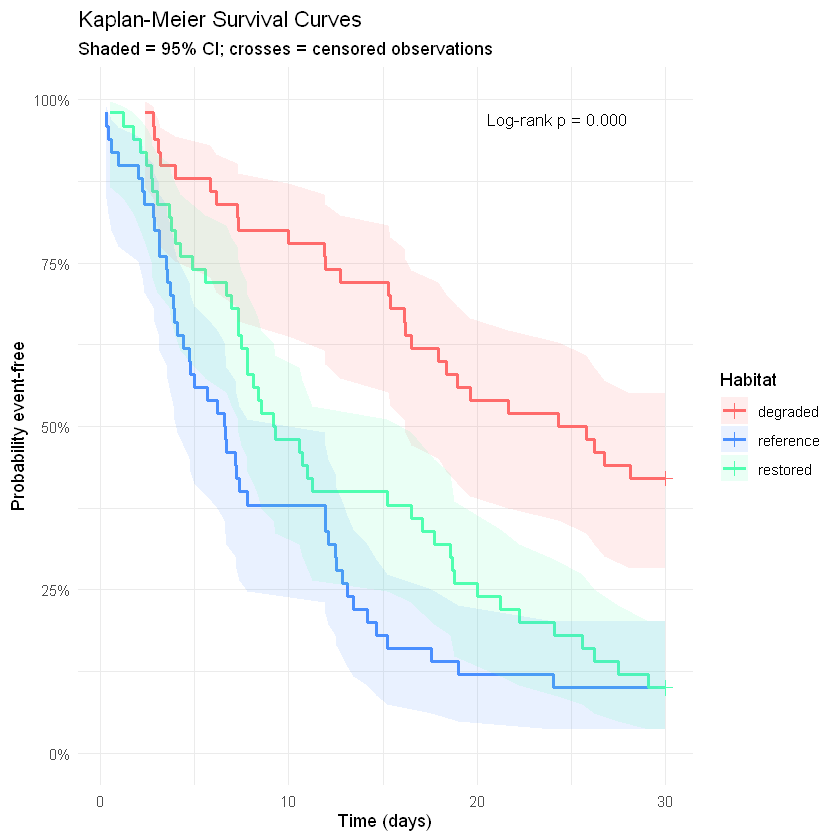

In [5]:
pal <- c(reference = "#4a8fff", restored = "#4fffb0", degraded = "#ff6b6b")

# survminer: standard publication format with risk table
survminer::ggsurvplot(
  km_fit,
  data              = habitat_data,
  pval              = TRUE,
  pval.method       = TRUE,
  conf.int          = TRUE,
  risk.table        = TRUE,
  risk.table.height = 0.25,
  surv.median.line  = "hv",
  palette           = unname(pal),
  legend.labs       = levels(habitat_data$habitat),
  xlab              = "Time (days)",
  ylab              = "Colonisation-free probability",
  title             = "Time to Invertebrate Colonisation by Habitat Type",
  ggtheme           = theme_minimal()
)

# ggplot2 version — fully customisable
km_tidy %>%
  mutate(strata = str_remove(strata, "habitat=")) %>%
  ggplot(aes(x = time, y = estimate, color = strata, fill = strata)) +
  geom_step(linewidth = 0.9) +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.12, color = NA) +
  geom_point(data = ~filter(.x, n.censor > 0), shape = 3, size = 2.5) +
  scale_color_manual(values = pal) +
  scale_fill_manual(values  = pal) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent) +
  annotate("text", x = 28, y = 0.97,
           label = sprintf("Log-rank p = %.3f", lr_p), hjust = 1, size = 3.5) +
  labs(title    = "Kaplan-Meier Survival Curves",
       subtitle  = "Shaded = 95% CI; crosses = censored observations",
       x = "Time (days)", y = "Probability event-free",
       color = "Habitat", fill = "Habitat") +
  theme_minimal()

---

## Reporting Results

In [6]:
print(summary(km_fit)$table[, c("records", "events", "median", "0.95LCL", "0.95UCL")])

# Standard format:
# "Kaplan-Meier curves were estimated for time to first invertebrate
#  colonisation. Median times were X days [95% CI: X, X] for reference,
#  X days [X, X] for restored, and X days [X, X] for degraded sites.
#  Curves differed significantly (log-rank chi2=X.X, df=2, p=.XXX).
#  Pairwise comparisons (BH-corrected) showed degraded sites had
#  significantly longer colonisation times than reference (p_adj=.XXX)
#  and restored sites (p_adj=.XXX)."
cat("Reporting guidance above.\n")

                  records events    median   0.95LCL  0.95UCL
habitat=reference      50     45  6.586061  4.101296 11.91598
habitat=restored       50     45  9.243881  7.321910 16.49152
habitat=degraded       50     29 25.064380 16.212515       NA
Reporting guidance above.


---

## Common Pitfalls

**1. Treating censored observations as failures or dropping them**  
Both bias the survival estimate. Censored observations contribute to the risk set up to their censoring time. Never recode them as events or exclude them.

**2. Using the log-rank test when curves cross**  
The log-rank test has maximum power when hazards are proportional. When curves cross — indicating early vs. late differences — use the Peto-Peto test (`rho=1`) or compare restricted mean survival times (RMST) instead.

**3. Over-interpreting the KM curve in the tail**  
When few subjects remain at risk, the estimate is unreliable and CIs are very wide. Always display the risk table and restrict interpretation to time points where n-at-risk is reasonably large.

**4. Ignoring informative censoring**  
KM assumes censoring is independent of the event. If sicker patients are more likely to drop out, the survival estimate is biased upward. This is a study design concern — not detectable statistically.

**5. Pairwise tests without multiple comparison correction**  
With k groups there are k(k−1)/2 pairwise tests. Always apply BH or Bonferroni correction.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*